In [27]:
import requests
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
import folium

In [29]:
url = "https://api.glasgow.gov.uk/traffic/v1/movement/sites"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    print(" Data successfully retrieved.")
else:
    print(f"API request failed with status code: {response.status_code}")
    data = None

 Data successfully retrieved.


In [31]:
if isinstance(data, list) and len(data) > 0:
    df = pd.DataFrame(data)
    print(" Columns in DataFrame:", df.columns.tolist())
    display(df.head())
else:
    print(" No valid data retrieved.")
    df = None

 Columns in DataFrame: ['siteId', 'from', 'to']


,siteId,from,to
0,GH020A_B,"{'description': 'Gallowgate west to Sword St',...","{'description': 'Gallowgate west to Sword St',..."
1,GJ3301_D,"{'description': 'Carmunnock Rd southbound', 'l...","{'description': 'Carmunnock Rd southbound', 'l..."
2,GH020A_A,"{'description': 'Gallowgate east to Sword St',...","{'description': 'Gallowgate east to Sword St',..."
3,GJ3301_C,{'description': 'Carmunnock Rd northbound to K...,{'description': 'Carmunnock Rd northbound to K...
4,GJ3301_B,{'description': 'Kings Park Ave westbound to C...,{'description': 'Kings Park Ave westbound to C...


In [33]:
if df is not None and not df.empty:
    if 'from' in df.columns:
        df['latitude'] = df['from'].apply(lambda x: x.get('lat') if isinstance(x, dict) else None)
        df['longitude'] = df['from'].apply(lambda x: x.get('long') if isinstance(x, dict) else None)
    print("Updated Columns:", df.columns.tolist())    
    display(df.head())

Updated Columns: ['siteId', 'from', 'to', 'latitude', 'longitude']


,siteId,from,to,latitude,longitude
0,GH020A_B,"{'description': 'Gallowgate west to Sword St',...","{'description': 'Gallowgate west to Sword St',...",55.8543754827825,-4.217259197086495
1,GJ3301_D,"{'description': 'Carmunnock Rd southbound', 'l...","{'description': 'Carmunnock Rd southbound', 'l...",55.821736212748405,-4.2561270616272875
2,GH020A_A,"{'description': 'Gallowgate east to Sword St',...","{'description': 'Gallowgate east to Sword St',...",55.85539015389372,-4.225769520669405
3,GJ3301_C,{'description': 'Carmunnock Rd northbound to K...,{'description': 'Carmunnock Rd northbound to K...,55.81925458152306,-4.255696036412074
4,GJ3301_B,{'description': 'Kings Park Ave westbound to C...,{'description': 'Kings Park Ave westbound to C...,55.820288451422314,-4.250775113480551


In [35]:
if df is not None and not df.empty and 'longitude' in df.columns and 'latitude' in df.columns:
    df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
    print("GeoDataFrame created successfully.")
    display(gdf.head())
else:
    print("DataFrame is empty or missing required columns. Cannot create GeoDataFrame.")
    gdf = None

GeoDataFrame created successfully.


,siteId,from,to,latitude,longitude,geometry
0,GH020A_B,"{'description': 'Gallowgate west to Sword St',...","{'description': 'Gallowgate west to Sword St',...",55.8543754827825,-4.217259197086495,POINT (-4.21726 55.85438)
1,GJ3301_D,"{'description': 'Carmunnock Rd southbound', 'l...","{'description': 'Carmunnock Rd southbound', 'l...",55.821736212748405,-4.2561270616272875,POINT (-4.25613 55.82174)
2,GH020A_A,"{'description': 'Gallowgate east to Sword St',...","{'description': 'Gallowgate east to Sword St',...",55.85539015389372,-4.225769520669405,POINT (-4.22577 55.85539)
3,GJ3301_C,{'description': 'Carmunnock Rd northbound to K...,{'description': 'Carmunnock Rd northbound to K...,55.81925458152306,-4.255696036412074,POINT (-4.2557 55.81925)
4,GJ3301_B,{'description': 'Kings Park Ave westbound to C...,{'description': 'Kings Park Ave westbound to C...,55.820288451422314,-4.250775113480551,POINT (-4.25078 55.82029)


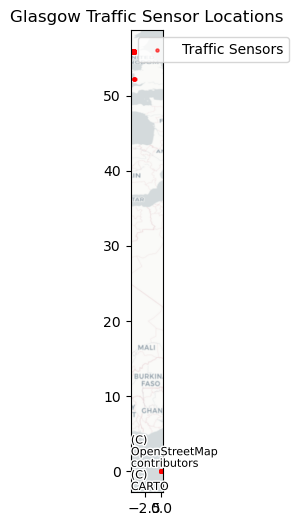

In [37]:
if gdf is not None and not gdf.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    gdf.plot(ax=ax, marker='o', color='red', markersize=5, alpha=0.6, label="Traffic Sensors")
    ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)
    ax.set_title("Glasgow Traffic Sensor Locations", fontsize=12)
    plt.legend()
    plt.show()
else:
    print("Cannot plot the map.")

In [39]:
if gdf is not None and not gdf.empty:
    m = folium.Map(location=[gdf.geometry.y.mean(), gdf.geometry.x.mean()], zoom_start=12)
    for _, row in gdf.iterrows():
        folium.Marker(
            location=[row.geometry.y, row.geometry.x],
            popup=f"ID: {row['siteId']}<br>From: {row.get('from', {}).get('description', 'Unknown')}",
            icon=folium.Icon(color="red")
        ).add_to(m)
    m.save("glasgow_traffic_sensors.html")
    
    print("Interactive map saved as 'glasgow_traffic_sensors.html'.")
else:
    print("Cannot create an interactive map.")

Interactive map saved as 'glasgow_traffic_sensors.html'.


In [41]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /Users/stuber
